In [1]:
%load_ext dotenv
%dotenv

In [2]:
from services.text_extractor_service import TextExtractorService
from tools.adapters.text_extractors.docx_text_extractor import DocxTextExtractor
from tools.adapters.text_extractors.pdf_plumber_text_extractor import PdfPlumberTextExtractor
from tools.adapters.web_searchers.openai_web_search import OpenAIWebSearch
from services.llm_web_search_service import LLMWebSearchService
from loguru import logger
from langsmith import traceable

In [3]:
text_extractor_service = TextExtractorService(docx_text_extractor=DocxTextExtractor(), 
                                              pdf_text_extractor=PdfPlumberTextExtractor())
response = text_extractor_service.extract_text_from_pdf("cv-template.pdf")
logger.info(f"Extracted text from PDF:\n{response}")

2026-09-26 16:50:20.531 | INFO     | __main__:<module>:4 - Extracted text from PDF:
T O M I S L AV A B R A M OV I C
JUNIOR DATA ANALYST
CONTACT CAREER OBJECTIVE
tomislav.abram@email.com Highly educated, innovative, and motivated data analysis professional with a
wealth of knowledge. Seeking a challenging and career-advancing position as a
(123) 456-7890
junior data analyst with Tech Firefly.
Sausalito, CA
LinkedIn
Twitter WORK EXPERIENCE
Junior Data Analyst
EDUCATION Sunbit
Bachelor's of Science July 2020 - current / San Francisco, CA
Computer Science Designed over 310 ad hoc queries with SQL in Cognos ReportNet,
examined reports, and presented findings in PowerPoint and Excel
University of San Francisco
Built 140 complex SQL reports to audit $2.5M of pay and benefits for over
2016 - 2020
1,300 employees
San Francisco, CA
Reengineered standard operational procedures that improved 22
GPA: 4.0 functional areas and data management
Awards Maintained reports with a 98% on-time delivery
2020

In [4]:
llm_web_search_service = LLMWebSearchService(llm_web_searcher=OpenAIWebSearch())
job_link_url = "https://www.indeed.com/viewjob?jk=aecc80988ae90fa8&from=shareddesktop_copy"
llm_response = llm_web_search_service.search(job_link_url)
logger.info(f"LLM Web Search Response:\n{llm_response}")

2026-09-26 16:50:20.563 | INFO     | tools.adapters.web_searchers.openai_web_search:search:43 - Searching for 'https://www.indeed.com/viewjob?jk=aecc80988ae90fa8&from=shareddesktop_copy' using OpenAI API
2026-09-26 16:50:31.371 | INFO     | __main__:<module>:4 - LLM Web Search Response:
Here is the structured summary of the job posting as requested:

- Job Title: AI Engineer  
- Company Name: CoreWeave  
- Location: Sunnyvale, CA  
- Employment Type: Full‑time  
- Salary or Compensation:  
  • Listed pay: $143 an hour  
  • Base salary range: $143,000 to $210,000 per year; actual starting salary determined based on experience, qualifications, interview performance, and location. Additional compensation includes discretionary bonus and equity awards  
- Required Qualifications / Skills:  
  • 3+ years of professional software engineering experience, strong proficiency in Go or Python  
  • Experience taking an AI application from prototype to production and supporting it  
  • Hands-on 

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

In [6]:
llm = ChatOpenAI()

In [7]:
tools = [*llm_web_search_service.as_tools(), *text_extractor_service.as_tools()]

In [8]:
tool_node = ToolNode(tools=tools)

In [9]:
llm_with_tools = llm.bind_tools(tools=tools)

In [10]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

In [11]:
sys_msg = SystemMessage(content="""
You are an expert career assistant that helps the user with questions related to jobs, careers, and applications.
Your key capabilities:
- You have access to the user's CV and can read its contents using the `extract_cv_text` tool.
- You can look up and extract details from job postings using the `job_posting_tool`.
- You can compare the user's CV against one or more job postings to determine suitability and provide tailored advice.
- You can suggest improvements to the CV for better alignment with target roles.

When answering:
1. First, think step-by-step about the user's request.
2. If the task requires reading the CV, call the CV extraction tool before answering.
3. If the task involves evaluating job postings, call the job posting tool to gather accurate information before answering.
4. Compare and reason about the information before providing your final response.

Response format:
- Be clear, concise, and structured with bullet points or numbered lists.
- Use section headers when possible (e.g., "Strengths", "Weaknesses", "Recommendations").
- Support your statements with evidence from the CV or job postings.
- Avoid vague language—be specific and factual.

Constraints:
- Do not invent or guess details about the user's experience or job postings.
- Only use information available in the CV, job postings, or provided context.
- Keep your tone professional, friendly, and supportive.
""")

In [12]:
@traceable
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [13]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

In [14]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [15]:
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", tool_node)

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

react_graph = builder.compile(checkpointer=memory)
config = {"configurable": {"thread_id": 1}}

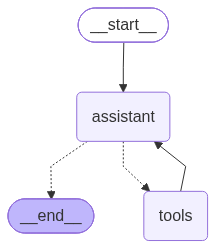

In [16]:
react_graph

In [17]:
messages = [HumanMessage(content="""
        Can you take a look at my CV ath the location 'cv-template.pdf'  and these 3 job applications and tell me whichone is the most suitable for my experience: 
        
        'https://www.indeed.com/viewjob?jk=247e94f9a28c544f&tk=1isdf5na1h72t810&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=744686732444f370&tk=1isns1midj72r8b4&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=01e2f371f220e42a&tk=1isns1midj72r8b4&from=serp&vjs=3'
        
        """)]

In [18]:
result = react_graph.invoke({"messages": messages}, config)

2026-09-26 16:50:35.542 | INFO     | tools.adapters.web_searchers.openai_web_search:search:43 - Searching for 'https://www.indeed.com/viewjob?jk=247e94f9a28c544f&tk=1isdf5na1h72t810&from=serp&vjs=3' using OpenAI API
2026-09-26 16:50:35.544 | INFO     | tools.adapters.web_searchers.openai_web_search:search:43 - Searching for 'https://www.indeed.com/viewjob?jk=744686732444f370&tk=1isns1midj72r8b4&from=serp&vjs=3' using OpenAI API
2026-09-26 16:50:35.545 | INFO     | tools.adapters.web_searchers.openai_web_search:search:43 - Searching for 'https://www.indeed.com/viewjob?jk=01e2f371f220e42a&tk=1isns1midj72r8b4&from=serp&vjs=3' using OpenAI API


In [19]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================


        Can you take a look at my CV ath the location 'cv-template.pdf'  and these 3 job applications and tell me whichone is the most suitable for my experience: 

        'https://www.indeed.com/viewjob?jk=247e94f9a28c544f&tk=1isdf5na1h72t810&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=744686732444f370&tk=1isns1midj72r8b4&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=01e2f371f220e42a&tk=1isns1midj72r8b4&from=serp&vjs=3'

        
================================== Ai Message ==================================
Tool Calls:
  extract_text (call_dElFFQF2nbWqNGvdwXX4if8p)
 Call ID: call_dElFFQF2nbWqNGvdwXX4if8p
  Args:
    filepath: cv-template.pdf
================================= Tool Message =================================
Name: extract_text

T O M I S L AV A B R A M OV I C
JUNIOR DATA ANALYST
CONTACT CAREER OBJECTIVE
tomislav.abram@email.com Highly educated, innovative,

In [20]:
messages = [HumanMessage(content="""For which one i am least suitable, and why ?""")]

In [21]:
result = react_graph.invoke({"messages": messages}, config)
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================


        Can you take a look at my CV ath the location 'cv-template.pdf'  and these 3 job applications and tell me whichone is the most suitable for my experience: 

        'https://www.indeed.com/viewjob?jk=247e94f9a28c544f&tk=1isdf5na1h72t810&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=744686732444f370&tk=1isns1midj72r8b4&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=01e2f371f220e42a&tk=1isns1midj72r8b4&from=serp&vjs=3'

        
================================== Ai Message ==================================
Tool Calls:
  extract_text (call_dElFFQF2nbWqNGvdwXX4if8p)
 Call ID: call_dElFFQF2nbWqNGvdwXX4if8p
  Args:
    filepath: cv-template.pdf
================================= Tool Message =================================
Name: extract_text

T O M I S L AV A B R A M OV I C
JUNIOR DATA ANALYST
CONTACT CAREER OBJECTIVE
tomislav.abram@email.com Highly educated, innovative,